# Class counter for `.txt` files
## *Contador de clases para archivos `.txt`*

In [1]:
import os
import matplotlib.pyplot as plt
import gc

## Configuration of Variables and functions
### *Configuración de variables y funciones*

In [2]:
annotations_path = "/mnt/datos_compartidos/PortafolioProyectos/imagenesFOTOS/labels"

classes = {
    "0": "arbol",
    "1": "poste",
    "2": "persona",
    "3": "vehiculo",
    "4": "senializacion",
    "5": "basurero",
    "6": "perro",
}

fontTitle = 24
fontAxis = 20

In [ ]:
def showGraphic(nameClass, valueClass, xLabel = "", yLabel = "", title = "", color = "green", rotationXlabel = 45, saveFigure = False, nameSave = "save.pdf"):  # Define function to plot a bar chart / Definir función para graficar un gráfico de barras
    plt.figure(figsize=(12, 8))  # Create new figure / Crear nueva figura
    plt.bar(nameClass, valueClass, color=color)  # Draw bar chart with given labels, values and color / Dibujar gráfico de barras con etiquetas, valores y color dados
    plt.xlabel(xLabel, fontsize=fontAxis)  # Set X-axis label / Establecer etiqueta del eje X
    plt.ylabel(yLabel, fontsize=fontAxis)  # Set Y-axis label / Establecer etiqueta del eje Y
    plt.title(title, fontsize=fontTitle)  # Set chart title / Establecer título del gráfico
    plt.xticks(rotation=rotationXlabel, fontsize=fontAxis)  # Rotate X-axis ticks and set font size / Rotar marcas del eje X y establecer tamaño de fuente
    plt.yticks(fontsize=fontAxis)  # Set Y-axis tick font size / Establecer tamaño de fuente de las marcas del eje Y
    plt.tight_layout(pad=3.0)  # Adjust layout with padding / Ajustar diseño con relleno
    plt.grid(axis='y', linestyle='--', alpha=0.5)  # Show horizontal dashed grid with 50% opacity / Mostrar cuadrícula horizontal discontinua con 50% de opacidad
    if saveFigure:  # If saving is enabled / Si guardar está habilitado
        plt.savefig(nameSave, dpi=300, bbox_inches='tight')  # Save figure as file at 300 DPI / Guardar figura como archivo a 300 DPI
    plt.show()  # Show the figure / Mostrar la figura

## Code
### *Código*

In [ ]:
globalCounter = {idClase: 0 for idClase in classes.keys()}  # Initialize global counter per class / Inicializar contador global por clase
perImgCounter = {}  # Dictionary to store per-image counts / Diccionario para almacenar conteos por imagen
maxCount = {idClase: {"filename": "", "count": 0} for idClase in classes.keys()}  # Track max count and filename per class / Rastrear conteo máximo y nombre de archivo por clase

for filename in os.listdir(annotations_path):  # Iterate over files in annotations folder / Iterar sobre archivos en carpeta de anotaciones
    if filename.endswith(".txt"):  # Process only .txt files / Procesar solo archivos .txt
        labelPath = os.path.join(annotations_path, filename)  # Build full path to label file / Construir ruta completa al archivo de etiquetas
        imgCounter = {idClase: 0 for idClase in classes.keys()}  # Initialize per-image counter per class / Inicializar contador por imagen por clase

        with open(labelPath, "r") as file:  # Open label file in read mode / Abrir archivo de etiquetas en modo lectura
            for line in file:  # Iterate over each line in file / Iterar sobre cada línea del archivo
                idClass = line.split()[0]  # Extract class id (first token) / Extraer id de clase (primer token)
                if idClass in imgCounter:  # Check if class id is known / Verificar si el id de clase es conocido
                    imgCounter[idClass] += 1  # Increment per-image count / Incrementar conteo por imagen
                    globalCounter[idClass] += 1  # Increment global count / Incrementar conteo global

        perImgCounter[filename] = imgCounter  # Store per-image counts in dictionary / Almacenar conteos por imagen en diccionario
        
        for idClass in classes.keys():  # Iterate over all classes / Iterar sobre todas las clases
            if imgCounter[idClass] > maxCount[idClass]["count"]:  # Check if current image has higher count / Verificar si la imagen actual tiene mayor conteo
                maxCount[idClass] = {"filename": filename, "count": imgCounter[idClass]}  # Update max count and filename for class / Actualizar conteo máximo y nombre de archivo para la clase

del perImgCounter, maxCount # Delete variables to free memory / Eliminar variables para liberar memoria
gc.collect() # Force garbage collector to release unused memory / Forzar el recolector de basura para liberar memoria no usada


29

In [5]:
for idClass, count in globalCounter.items():  # Iterate over global counts / Iterar sobre conteos globales
    print(f"{classes[idClass]}: {count}")  # Print class name and count / Imprimir nombre de clase y conteo

arbol: 340
poste: 760
persona: 0
vehiculo: 0
senializacion: 0
basurero: 0
perro: 0


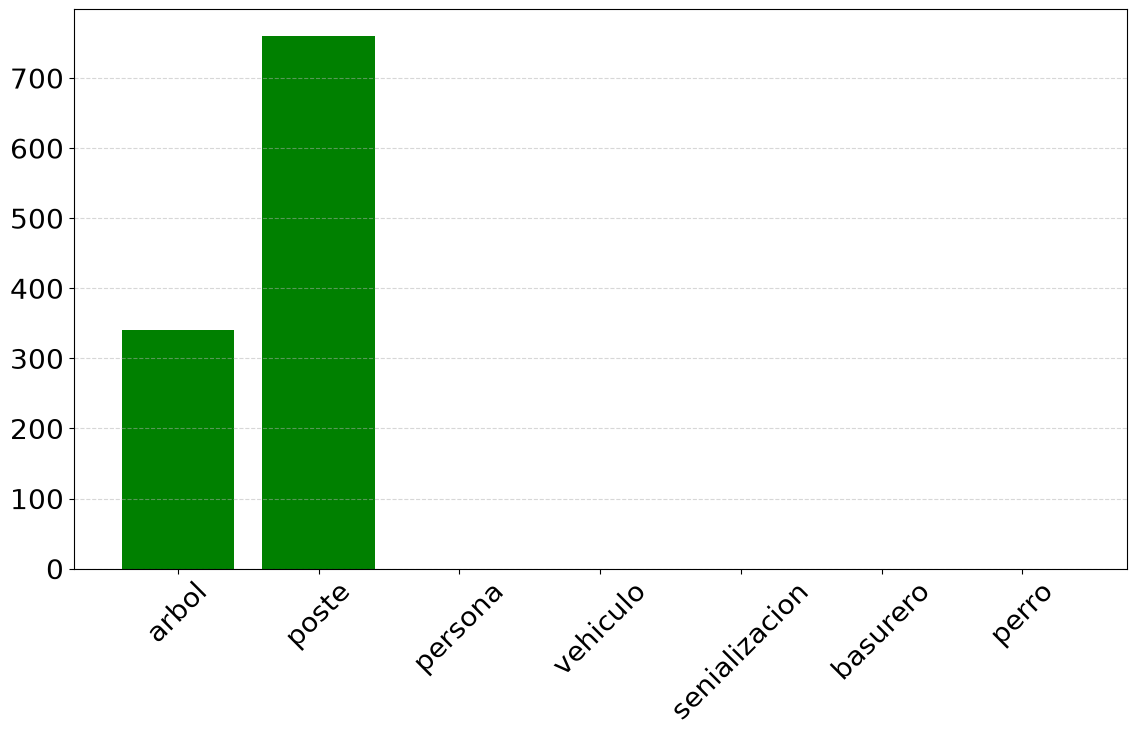

In [ ]:
nameClasses = [classes[id] for id in globalCounter.keys()]  # Get class names in the same order as the global counter keys / Obtener nombres de clase en el mismo orden que las claves del contador global
values = [globalCounter[id] for id in globalCounter.keys()]  # Get counts corresponding to each class id / Obtener conteos correspondientes a cada id de clase

showGraphic(nameClass=nameClasses, valueClass=values)  # Plot bar chart with class names and their counts / Graficar barras con nombres de clase y sus conteos